In [1]:
import numpy as np
import pandas as pd
import sys
import os
sys.path.append(os.path.abspath('../../..'))
import matplotlib.pyplot as plt
from scripts import nodes as n
from scripts import elements as e
from scripts import material_params as mat
from scipy.linalg import eigh
import plotly.graph_objects as go

In [2]:
nodes = []
nodal_values = np.loadtxt('../../../text_files/nodes_minimal_model_.txt', delimiter=',')
for i in range(nodal_values.shape[0]):
  nodes.append(n.nodes(nodal_values[i, 0], nodal_values[i, 1], nodal_values[i, 2]))

In [3]:
# Truss parameters
E = 210e9  # Young's modulus in Pascals
nu = 0.3   # Poisson's ratio
G = E / (2 * (1 + nu))  # Shear modulus in Pascals
m = 6.7504 * 10 ** 6 #kg
d1 = 0.8 #m
d2 = 1.8 #m
t1 = 0.03 #m
t2 = 0.08 #m
L_truss_element_y = 15 #m
h_truss = 18 #m
Aeq, Ieqy, Ieqz, b_eq, h_eq = mat.effective_truss_stiffness(d1, d2, t1, t2, h_truss, L_truss_element_y) 
L = 237.5
rho_truss = m / (L * Aeq)
It = (b_eq * h_eq**3 / 3) * (1 - 0.63 * (h_eq / b_eq) * (1 - (h_eq**4 / (12 * b_eq**4)))) *0.06
k = 0.08
Ip  = Ieqy + Ieqz
ep_K = [E, G, Aeq, Ieqy, Ieqz, It, k]
ep_m = [rho_truss, Aeq, Ieqy, Ieqz, Ip]

k = 5/6
rho = 7850 #kg/m^3
E=210e9 #Pa
G = E/(2*(1+nu)) #Pa
nu = 0.3 #Poisson's ratio
k_fender = mat.stiffness_fenders()
Iy_connect, Iz_connect, Ip_connect, It_connect, A_connect = mat.stiffness_connecting_beams()
ep_K_connect = [E, G, A_connect, Iy_connect, Iz_connect, It_connect, k]
ep_m_connect = [rho, A_connect, Iy_connect, Iz_connect, Ip_connect]


E = 210e9 #Pa
# Material parameters retaining wall
t_eff = 1#m
A_eq_wall, I_eqy_wall, I_eqz_wall, b_eq_wall, rho_wall = mat.effective_retaining_wall_stiffness(t_eff)
Ip_wall = I_eqy_wall + I_eqz_wall
It_wall = (b_eq_wall * t_eff**3 / 3) * (1 - 0.63 * (b_eq_wall / t_eff) + 0.052 * (b_eq_wall / t_eff) **5)
ep_K_wall = [E, G, A_eq_wall, I_eqy_wall, I_eqz_wall, It_wall, k]
ep_m_wall = [rho_wall, A_eq_wall, I_eqy_wall, I_eqz_wall, Ip_wall]
print(rho_wall)

print(mat.effective_retaining_wall_stiffness(t_eff))
print(mat.effective_truss_stiffness(d1, d2, t1, t2, L_truss_element_y, h_truss))
print(mat.stiffness_connecting_beams())

458.02196474590005
(68, 4196.196078431372, 1362.1960784313726, 3.090909090909091, 458.02196474590005)
(3.17049530600282, 301.6, 256.36, 7.297687177237888, 7.91545310187776)
(482.5900664338916, 0.32040827013808765, 482.9104747040297, 482.9104747040297, 2.976973198541688)


In [4]:
elements = []
element_nodes = np.loadtxt('../../../text_files/element_nodes3.txt', dtype=int)
for i in range(element_nodes.shape[0]):
    if element_nodes[i, 2] == 0:
        elements.append(e.elements(nodes[element_nodes[i, 0] - 1], nodes[element_nodes[i, 1] - 1], ep_K, ep_m))
    elif element_nodes[i, 2] == 1:
        elements.append(e.elements(nodes[element_nodes[i, 0] - 1], nodes[element_nodes[i, 1] - 1], ep_K_wall, ep_m_wall))
    elif element_nodes[i, 2] == 2:
        elements.append(e.elements(nodes[element_nodes[i, 0] - 1], nodes[element_nodes[i, 1] - 1], ep_K_connect, ep_m_connect))

element_nodes = np.loadtxt('../../../text_files/element_nodes.txt', dtype=int)


dofs = n.degrees_of_freedom(nodes)

element_locs = []

for (nA, nB) in element_nodes:
    dofs_A = dofs[f'dof_{nA}']
    dofs_B = dofs[f'dof_{nB}']
    element_locs.append(np.hstack((dofs_A, dofs_B)))



# Parameter space for axial stiffness of the fenders

Loop  0 completed
Loop  1 completed
Loop  2 completed
Loop  3 completed
Loop  4 completed
Loop  5 completed
Loop  6 completed
Loop  7 completed
Loop  8 completed
Loop  9 completed
Loop  10 completed
Loop  11 completed
Loop  12 completed
Loop  13 completed
Loop  14 completed
Loop  15 completed
Loop  16 completed
Loop  17 completed
Loop  18 completed
Loop  19 completed
Loop  20 completed
Loop  21 completed
Loop  22 completed
Loop  23 completed
Loop  24 completed
Loop  25 completed
Loop  26 completed
Loop  27 completed
Loop  28 completed
Loop  29 completed
Loop  30 completed
Loop  31 completed
Loop  32 completed
Loop  33 completed
Loop  34 completed
Loop  35 completed
Loop  36 completed
Loop  37 completed
Loop  38 completed
Loop  39 completed
Loop  40 completed
Loop  41 completed
Loop  42 completed
Loop  43 completed
Loop  44 completed
Loop  45 completed
Loop  46 completed
Loop  47 completed
Loop  48 completed
Loop  49 completed
Loop  50 completed
Loop  51 completed
Loop  52 completed
Loo

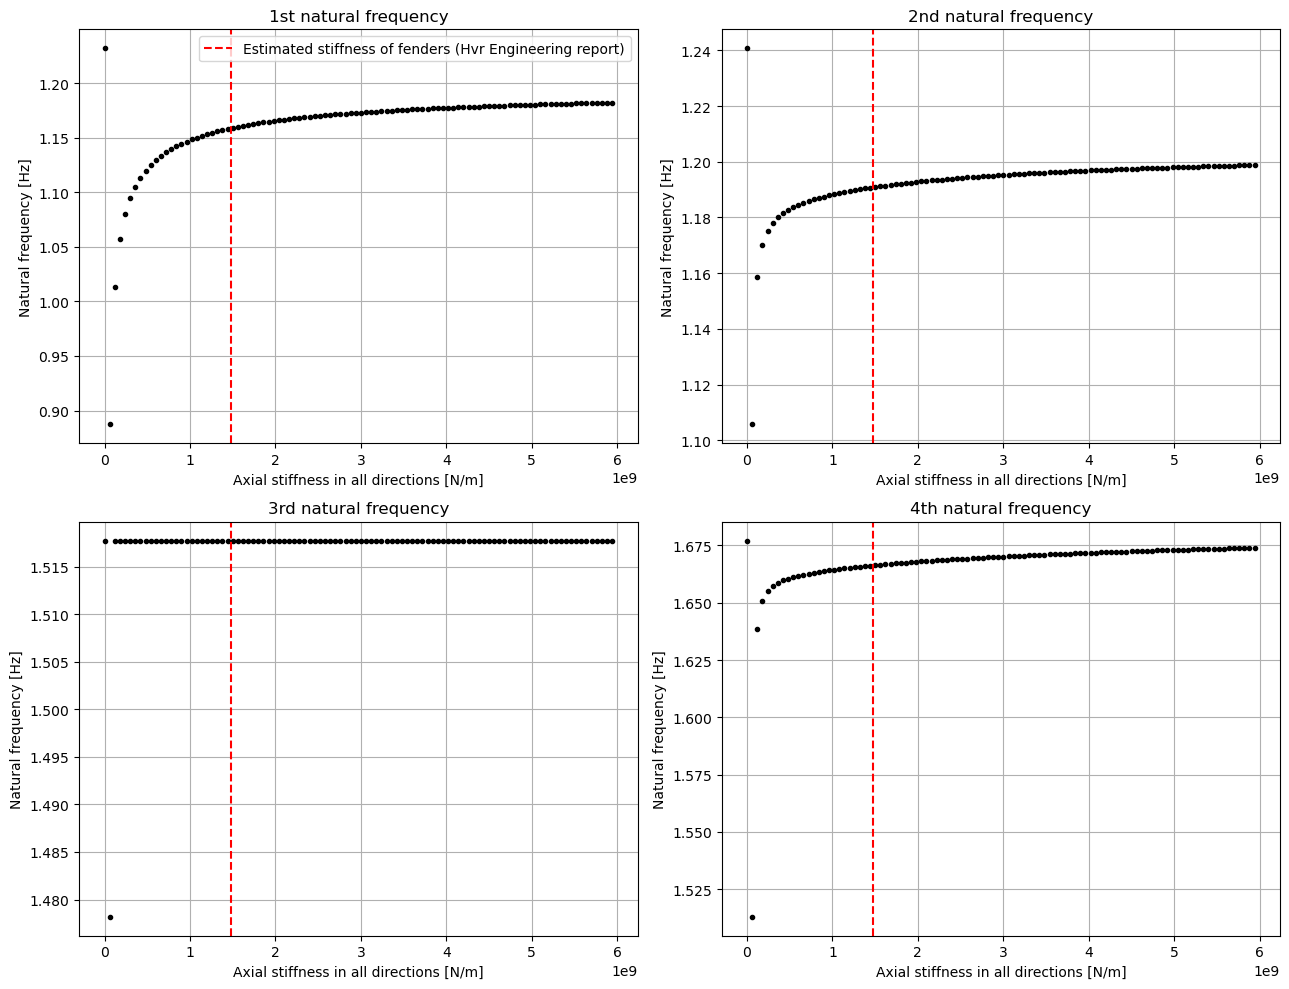

In [5]:
k_fender_max = 0.6e10
N = 100

k_fender = np.arange(0, k_fender_max, k_fender_max/N)



fig, axs = plt.subplots(2, 2, figsize=(13, 10))

eig_freqs = []
N = len(nodes)
DOFS_per_node = 6

for i in range(len(k_fender)):
    K_global = np.zeros((N * DOFS_per_node, N * DOFS_per_node))
    M_global = np.zeros((N * DOFS_per_node, N * DOFS_per_node))

    K_locs = []
    M_locs = []



    for j in range(len(element_locs)):
        K_global[np.ix_(element_locs[j], element_locs[j])] += elements[j][-1]
        M_global[np.ix_(element_locs[j], element_locs[j])] += elements[j][-2]

    K_global = 0.5 * (K_global + K_global.T)
    M_global = 0.5 * (M_global + M_global.T)

    fender_dofs = [70, 75, 79, 83, 87, 91, 95, 99, 103, 107, 111, 115, 119, 123, 128]
    k_fender_dofs = [dofs[f'dof_{i+1}'][2] for i in fender_dofs]
    for dof in k_fender_dofs:
        K_global[dof, dof] += k_fender[i]



    indices_to_remove = np.hstack((dofs['dof_1'][0:3], dofs['dof_129'][0:2]))
    keep_indices = np.setdiff1d(np.arange(N * DOFS_per_node), indices_to_remove)
    K_global_reduced = K_global[np.ix_(keep_indices, keep_indices)]
    M_global_reduced = M_global[np.ix_(keep_indices, keep_indices)]

    eigvals_global, eigvecs_global = eigh(K_global_reduced, M_global_reduced)


    tol = 1e-6
    positive = eigvals_global > tol
    eigvals_global = eigvals_global[positive]
    eigvecs_global = eigvecs_global[:, positive]

    frequencies_rad = np.sqrt(eigvals_global)
    frequencies_hz = frequencies_rad / (2 * np.pi)

    eig_freqs.append(frequencies_hz[0:10])
    axs[0, 0].plot(k_fender[i], eig_freqs[i][0], '.', color='black')
    axs[0, 1].plot(k_fender[i], eig_freqs[i][1], '.', color='black')
    axs[1, 0].plot(k_fender[i], eig_freqs[i][2], '.', color='black')
    axs[1, 1].plot(k_fender[i], eig_freqs[i][3], '.', color='black')


    print('Loop ', i, 'completed')

for ax in axs.flat:
    ax.grid()
plt.xlabel('Axial  stiffness of one fender [N/rad]')
plt.ylabel('natural frequency [Hz]')
plt.title('Natural frequency vs axial stiffness of a fender')
axs[0, 0].axvline(x=mat.stiffness_fenders(), color='red', linestyle='--', label='Estimated stiffness of fenders (Hvr Engineering report)')
axs[0, 1].axvline(x=mat.stiffness_fenders(), color='red', linestyle='--')
axs[1, 0].axvline(x=mat.stiffness_fenders(), color='red', linestyle='--')
axs[1, 1].axvline(x=mat.stiffness_fenders(), color='red', linestyle='--')
axs[0, 0].set_title('1st natural frequency')
axs[0, 1].set_title('2nd natural frequency')
axs[1, 0].set_title('3rd natural frequency')
axs[1, 1].set_title('4th natural frequency')

axs[0, 0].set_xlabel('Axial stiffness in all directions [N/m]')
axs[0, 1].set_xlabel('Axial stiffness in all directions [N/m]')
axs[1, 0].set_xlabel('Axial stiffness in all directions [N/m]')
axs[1, 1].set_xlabel('Axial stiffness in all directions [N/m]')
axs[0, 0].set_ylabel('Natural frequency [Hz]')
axs[0, 1].set_ylabel('Natural frequency [Hz]')
axs[1, 0].set_ylabel('Natural frequency [Hz]')
axs[1, 1].set_ylabel('Natural frequency [Hz]')

axs[0, 0].legend()
plt.tight_layout()
plt.show()
